# <a id='toc1_'></a>[Digital signal processing. Lab1](#toc0_)

In [1]:
%%capture 
%pip install matplotlib 
%pip install numpy
%pip install scipy

**Table of contents**<a id='toc0_'></a>    
- [Digital signal processing. Lab1](#toc1_)    
  - [Task1](#toc1_1_)    
    - [Task1(a)](#toc1_1_1_)    
    - [Task1(b)](#toc1_1_2_)    
    - [Task1(c)](#toc1_1_3_)    
  - [Task2](#toc1_2_)    
    - [Task2(a)](#toc1_2_1_)    
    - [Task2(b)](#toc1_2_2_)    
  - [Task3](#toc1_3_)    
  - [Task4](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Task1](#toc0_)

Периодический сигнал прямоугольных импульсов $x(t)$ можно представить в виде ряда Фурье $x(t)^*$. Ограничимся конечным числом $N$ слагаемых, тогда ряд Фурье можно записать в виде:

$$x(t)^* = \frac{a_0}{2} + \sum_{n=1}^{N} [a_n \cos(nwt) + b_n \sin(nwt)],$$

где коэффициенты ряда определяются по формулам:

$$a_0 = \frac{2}{T} \int_{t_0}^{t_0+T} x(t) dt ,$$

$$a_n = \frac{2}{T} \int_{t_0}^{t_0+T} x(t) \cdot \cos(nwt) dt$$

$$b_n = \frac{2}{T} \int_{t_0}^{t_0+T} x(t) \cdot \sin(nwt) dt$$

### <a id='toc1_1_1_'></a>[Task1(a)](#toc0_)

а) Напишите программу, которая выведет на экран аппроксимированную функцию $x(t)^*$,

In [1]:
from typing import Callable, List
from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [3]:
"""Функции для вычисления коэффициентов тригонометрического ряда Фурье.

Этот модуль предоставляет функции для численного расчета коэффициентов
a0, an и bn с использованием определенных интегралов.

Args:
    x (Callable[[float], float]): Исходная периодическая функция x(t).
        Принимает время t в секундах [с].
        Возвращает амплитуду в произвольных единицах (например, Вольты [В], Метры [м]).
    T (float): Период сигнала T (длительность одного полного цикла) в секундах [с].
    t0 (float, optional): Начальное время интегрирования t0 (смещение по времени) в секундах [с].
        По умолчанию 0.
    n (int): Порядок гармоники n (целое число >= 1).
        Используется для вычисления 'an' и 'bn'.
    w (float): Циклическая частота w, вычисляемая как (2 * pi / T) в радианах в секунду [рад/с].
        Используется для вычисления 'an' и 'bn'.

Returns:
    float: Вычисленное значение соответствующего коэффициента (a0, an или bn).
        Единица измерения совпадает с амплитудой входной функции x(t).
"""


def compute_a0_coef_fourier(x: Callable[[float], float], T: float, t0: float = 0) -> float:
    return (2 / T) * quad(lambda t: x(t), t0, t0 + T)[0]

def compute_an_coef_fourier(x: Callable[[float], float], n: int, T: float, w: float, t0: float = 0) -> float:
    return (2 / T) * quad(lambda t: x(t) * np.cos(n * w * t), t0, t0 + T)[0]

def compute_bn_coef_fourier(x: Callable[[float], float], n: int, T: float, w: float, t0: float = 0) -> float:
    return (2 / T) * quad(lambda t: x(t) * np.sin(n * w * t), t0, t0 + T)[0]

In [4]:
def reconstruct_signal_fourier(
    t: float | np.ndarray, 
    a0: float, 
    an_coeffs: List[float], 
    bn_coeffs: List[float], 
    w: float
) -> float | np.ndarray:
    """Восстанавливает сигнал x*(t) суммированием ряда Фурье.

    Реализует формулу частичной суммы ряда:
    x*(t) = (a0 / 2) + sum(an * cos(nwt) + bn * sin(nwt))

    Args: 
        t: Time point(s) in seconds. Can be a single float or a NumPy array of time values.


    Returns:
        Значение восстановленного сигнала в точке(ах) t.
    """
    
    signal = a0 / 2
    
    for n, (an, bn) in enumerate(zip(an_coeffs, bn_coeffs), start=1):
        harmonic_val = an * np.cos(n * w * t) + bn * np.sin(n * w * t)
        signal += harmonic_val
        
    return signal

In [5]:
T = 2 * np.pi
w = 2 * np.pi / T

amount_harmonic = 30

x_func = lambda t: np.sign(np.sin(w * t))

a0_coef = compute_a0_coef_fourier(x_func, T)

an_coeffs = np.array([compute_an_coef_fourier(x_func, n, T, w) for n in range(1, amount_harmonic + 1)])
bn_coeffs = np.array([compute_bn_coef_fourier(x_func, n, T, w) for n in range(1, amount_harmonic + 1)])

t_values = np.linspace(0,2 * T, 1000)

x_original = x_func(t_values)
x_approximation = reconstruct_signal_fourier(t_values, a0_coef, an_coeffs, bn_coeffs, w)

В случае если функция $x(t)$, описывающая сигнал, является нечетной, $-x(t)=x(-t)$, тогда все коэффициенты $a_0$, $a_n$ равны нулю, формула (73) примет вид:

$$x(t)=\sum_{n=1}^{\infty} b_n \sin(nwt). \quad (77)$$

Если функция $x(t)$, описывающая сигнал, является четной, $x(t)=x(-t)$, тогда все коэффициенты $b_n$ равны нулю, формула (73) примет вид:

$$x(t)=\frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos(nwt). \quad (78)$$

In [6]:
TOLERANCE = 1e-10

t_test = T / 4
val_plus = x_func(t_test)
val_minus = x_func(-t_test)

if np.isclose(val_minus, -val_plus):
    assert np.isclose(a0_coef, 0, atol=TOLERANCE), \
        f"a0 should be 0, but a0={a0_coef}"
    assert np.allclose(an_coeffs, 0, atol=TOLERANCE), \
        f"an coefficients should be 0, max deviation is {np.max(np.abs(an_coeffs))}"

elif np.isclose(val_minus, val_plus):
    assert np.allclose(bn_coeffs, 0, atol=TOLERANCE), \
        f"bn coefficients should be 0, max deviation is {np.max(np.abs(bn_coeffs))}"

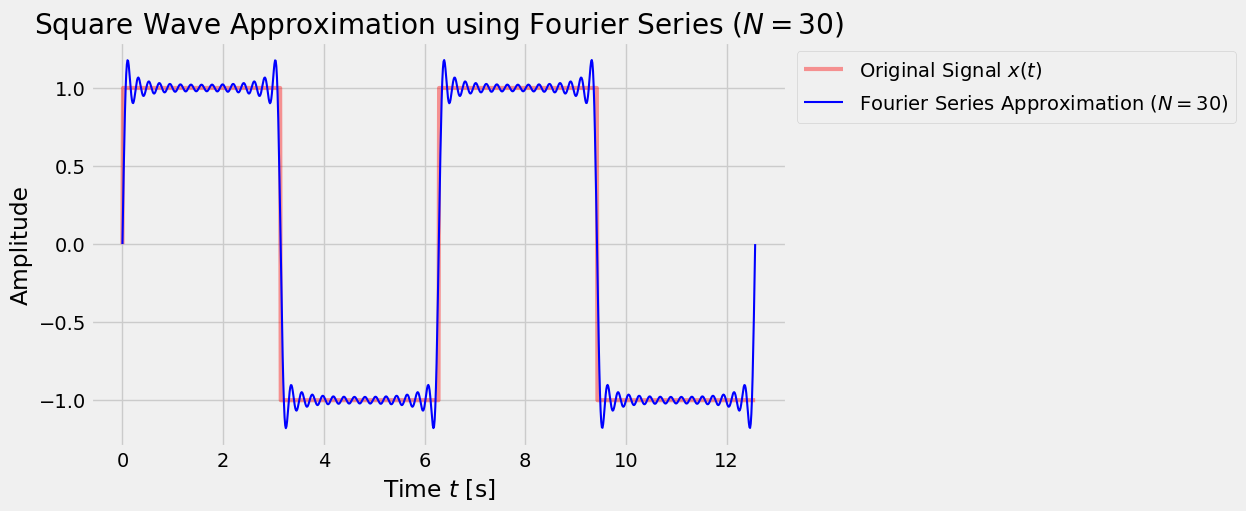

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(t_values, x_original, 'r', linewidth=3, alpha=0.4, label='Original Signal $x(t)$')
plt.plot(t_values, x_approximation, 'b', linewidth=1.5, label=f'Fourier Series Approximation ($N={amount_harmonic}$)')

plt.title(f"Square Wave Approximation using Fourier Series ($N={amount_harmonic}$)")
plt.xlabel("Time $t$ [s]")
plt.ylabel("Amplitude")

plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.show()

### <a id='toc1_1_2_'></a>[Task1(b)](#toc0_)

b) Постройте график погрешности приближения $x(t)$ функцией $x(t)^*$. Погрешность приближения можно определить по формуле $\varepsilon = x(t) - x(t)^*$.

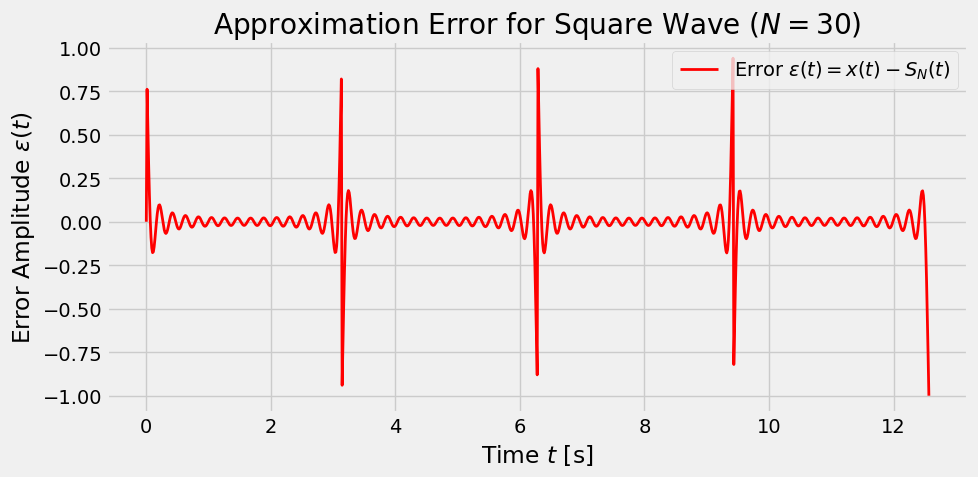

In [8]:
epsilon_error = x_original - x_approximation

plt.figure(figsize=(10, 5))
plt.plot(t_values, epsilon_error, 'r', linewidth=2, label=r'Error $\varepsilon(t) = x(t) - S_N(t)$')
plt.title(f"Approximation Error for Square Wave ($N={amount_harmonic}$)")
plt.ylabel(r"Error Amplitude $\varepsilon(t)$")
plt.xlabel("Time $t$ [s]")

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### <a id='toc1_1_3_'></a>[Task1(c)](#toc0_)
[(c)](#toc1_1_3_) Реализуйте класс, который позволит Вам производить разложение в ряд Фурье любой функции $x(t)$.

In [56]:
class FourierSeriesCalculator:
    """
    This class applies the method of numerical integration to directly calculate the coefficients 
    of a trigonometric Fourier expansion.
    """
    def __init__(self, func: Callable[[float], float], T: float, t0: float = 0, amount_harmonic: int = 10):
    
        self._func = func
        self._T = T
        self._t0 = t0
        self._N = amount_harmonic
        self._w = 2 * np.pi / T
        
        self.__a0 = None
        self.__an = None
        self.__bn = None
        
        self.__is_even = False
        self.__is_odd = False
        self.__is_fit = False

    @property
    def func(self):
        return self._func
    
    @func.setter
    def func(self, value):
        self._func = value
        self.__is_fit = False 
        print("INFO: Function changed. Please run .fit() again.")

    @property
    def T(self):
        return self._T
    
    @T.setter
    def T(self, value):
        self._T = value
        self._w = 2 * np.pi / value 
        self.__is_fit = False
        print("INFO: Period T changed. Please run .fit() again.")

    @property
    def amount_harmonic(self):
        return self._N
    
    @amount_harmonic.setter
    def amount_harmonic(self, value):
        self._N = value
        self.__is_fit = False
        print("INFO: Amount of harmonics changed. Please run .fit() again.")
        
    @property
    def a0(self) -> float:
        if not self.__is_fit:
            raise RuntimeError("Model is not fitted! Call .fit() first.")
        return self.__a0

    @property
    def an(self) -> np.ndarray:
        if not self.__is_fit:
            raise RuntimeError("Model is not fitted! Call .fit() first.")
        return self.__an

    @property
    def bn(self) -> np.ndarray:
        if not self.__is_fit:
            raise RuntimeError("Model is not fitted! Call .fit() first.")
        return self.__bn

    def __check_symmetry(self) -> None:
        test_points = np.array([self._T/4, self._T/8, self._T/3]) 
        
        y_minus = np.array([self._func(-t) for t in test_points])
        y_plus = np.array([self._func(t) for t in test_points])
        
        self.__is_odd = False
        self.__is_even = False

        if np.allclose(y_minus, -y_plus, atol=1e-8):
            self.__is_odd = True
            print("INFO: Function is ODD. Coefficients a_n set to 0")
        elif np.allclose(y_minus, y_plus, atol=1e-8):
            self.__is_even = True
            print("INFO: Function is EVEN. Coefficients b_n set to 0")
        else:
            print("INFO: General function type.")
    
    def __calculate_a0(self) -> None:
        if self.__is_odd:
            self.__a0 = 0.0
        else:
            self.__a0 = (2 / self._T) * quad(lambda t: self._func(t), self._t0, self._t0 + self._T)[0]  

    def __calculate_an(self) -> None:
        if self.__is_odd:
            self.__an = np.zeros(self._N)
        else:
            _compute_nth_an = lambda n: (2 / self._T) * quad(
                lambda t: self._func(t) * np.cos(n * self._w * t),
                self._t0, self._t0 + self._T
            )[0]
            
            self.__an = np.array([_compute_nth_an(n) for n in range(1, self._N + 1)])

    def __calculate_bn(self) -> None:
        if self.__is_even:
            self.__bn = np.zeros(self._N)
        else:
            _compute_nth_bn = lambda n: (2 / self._T) * quad(
                lambda t: self._func(t) * np.sin(n * self._w * t),
                self._t0, self._t0 + self._T
            )[0]
            
            self.__bn = np.array([_compute_nth_bn(n) for n in range(1, self._N + 1)])

    def fit(self):
        self.__a0 = None
        self.__an = None
        self.__bn = None
        
        self.__check_symmetry()
        self.__calculate_a0()
        self.__calculate_an()
        self.__calculate_bn()
        
        self.__is_fit = True
        print("INFO: Fit complete.")

    def predict(self, t: float | np.ndarray) -> float | np.ndarray:
        """Reconstructs the signal at time `t` using the calculated Fourier coefficients.
        
        Args:
            t: Time point(s) in seconds. Can be a single float or a NumPy array 
               of time values.

        Returns:
            The reconstructed signal amplitude at the specified time(s). 
            Returns a float if `t` is a scalar, or an ndarray if `t` is an array.

        Raises:
            RuntimeError: If the model has not been fitted (i.e., `fit()` has not been called).
        """
        
        if not self.__is_fit:
            raise RuntimeError("Model is not fitted! Please call .fit() before .predict().")
                
        signal = self.__a0 / 2
    
        for n, (an, bn) in enumerate(zip(self.__an, self.__bn), start=1):
            harmonic_val = an * np.cos(n * self._w * t) + bn * np.sin(n * self._w * t)
            signal += harmonic_val
        
        return signal

## <a id='toc1_2_'></a>[Task2](#toc0_)

Убедиться в правильности работы алгоритма, который был разработан Вами в пункте 1 данной лабораторной работы. Для этого подать на вход программы вместо прямоугольного импульса сигнал косинуса $x(t) = A \cos(wt)$ с частотой равной $f = 100$ Гц, где $A$ — заданная амплитуда сигнала.

а) Воспользоваться прямым преобразованием Фурье и убедиться, что в спектре сигнала $x(t) = A \cos(wt)$ присутствует только выделенная частота $f$. На рис. 1 спектр данного сигнала будет представлен в виде сплошной темной линии.

б) Из результатов работы вашего алгоритма определить спектральный коэффициент $a_n$ и на график спектра разместить частоту сигнала, которой он соответствует. На рис. 1 спектр будет соответствовать пунктирной оранжевой линии.

**Замечание:**

а) Циклическая частота $w$ связана с частотой сигнала по формуле: $w = 2 \cdot \pi \cdot f$ <br>
б) В качестве прямого преобразования Фурье можно использовать функцию преобразования Фурье, встроенную в Python (`numpy.fft`)

### <a id='toc1_2_1_'></a>[Task2(a)](#toc0_)

In [106]:
f_2 = 100.0           
A_2 = 10.0   
Fs_2 = 2000 # частота дискретизации
dt_2 = 1.0 / Fs # шаг по времени         
w_2 = 2 * np.pi * f_2   

func_cos = lambda t: A_2 * np.cos(w_2 * t)

In [144]:
t_vals_2 = np.arange(0, 1, dt_2)
signal_y_vals_2 = func_cos(t_vals)

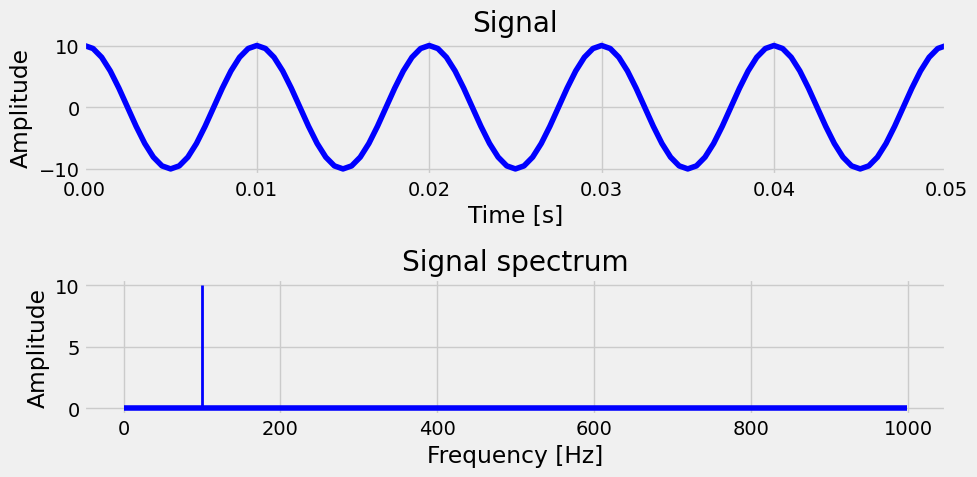

In [145]:
spectrum = np.fft.fft(signal_y_vals_2)

N = signal_y_vals_2.shape[-1]

freq = np.fft.fftfreq(N, dt)

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t_vals, signal_y_vals_2, 'b')
plt.title('Signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

### <a id='toc1_2_2_'></a>[Task2(b)](#toc0_)

In [219]:
T_period_2 = 1.0 / f_2

In [220]:
my_calc = FourierSeriesCalculator(func_cos, T_period_2, amount_harmonic = 5)
my_calc.fit()

INFO: Function is EVEN. Coefficients b_n set to 0
INFO: Fit complete.


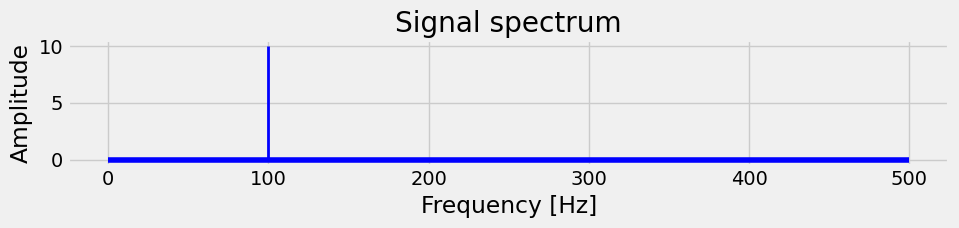

In [221]:
my_freqs = np.arange(1, my_calc.amount_harmonic + 1) * f
my_freqs = np.insert(my_freqs, 0, 0)
my_an_coeffs = np.insert(my_calc.an, 0, my_calc.a0/2)


plt.figure(figsize=(10, 2.5))
markerline, stemlines, baseline = plt.stem(my_freqs, my_an_coeffs)

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()


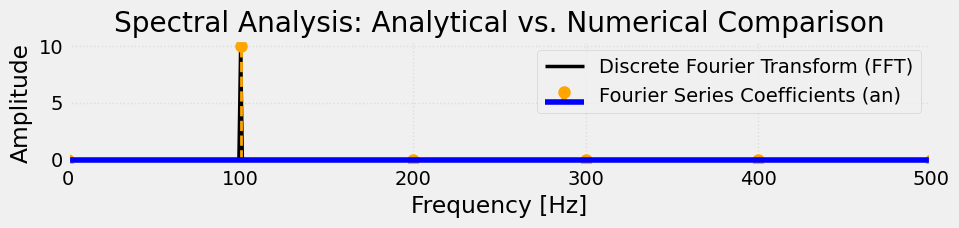

In [148]:
plt.figure(figsize=(10, 2.5))

mask = freq >= 0
plt.plot(freq[mask], (np.abs(spectrum[mask]) / N) * 2, 
         color='black', label='Discrete Fourier Transform (FFT)', linewidth=2.5)
markerline, stemlines, baseline = plt.stem(my_freqs, my_an_coeffs, label='Fourier Series Coefficients (an)')
plt.setp(stemlines, linestyle='--', color='orange', linewidth=2) 
plt.setp(markerline, color='orange', markersize=8)
plt.setp(baseline, color='blue', markersize=8)

plt.title('Spectral Analysis: Analytical vs. Numerical Comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, 500)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## <a id='toc1_3_'></a>[Task3](#toc0_)

Определить спектр прямоугольного сигнала с помощью встроенной функции `fft` и сопоставить определенный спектр с тем, который предсказывает ваш алгоритм.


In [3]:
import numpy as np

In [4]:
f_3 = 250
Fs_3 = 4000 
dt_3 = 1.0 / Fs_3 # шаг по времени         
w_3 = 2 * np.pi * f_3   

func_meandr = lambda t: np.sign(np.sin(w_3 * t))

In [5]:
t_vals_3 = np.arange(0, 1, dt_3)
signal_y_vals_3 = func_meandr(t_vals_3)

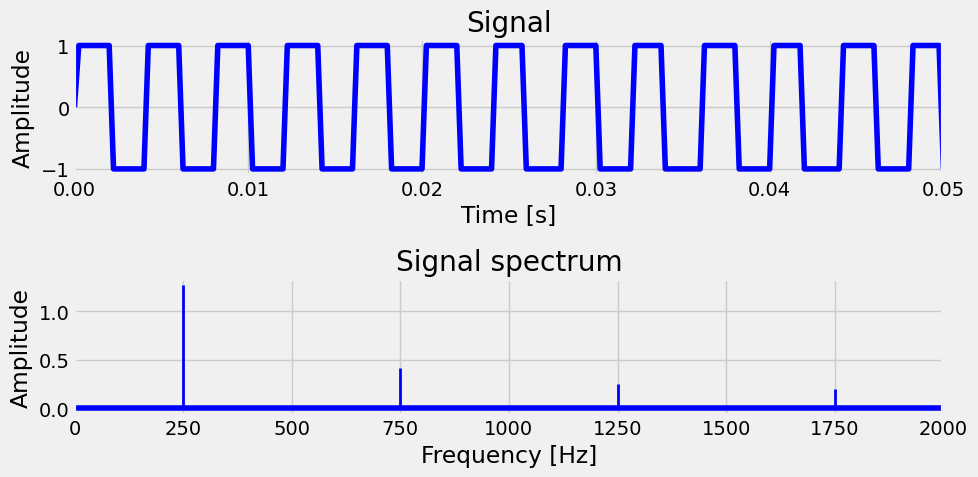

In [6]:
spectrum = np.fft.fft(signal_y_vals_3)

N = signal_y_vals_3.shape[-1]

freq = np.fft.fftfreq(N, dt_3)

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t_vals_3, signal_y_vals_3, 'b')
plt.title('Signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.xlim(0, 2000)
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [248]:
T_period_3 = 1.0 / f_3

In [249]:
my_calc = FourierSeriesCalculator(func_meandr, T_period_3, amount_harmonic = 15)
my_calc.fit()

INFO: Function is ODD. Coefficients a_n set to 0
INFO: Fit complete.


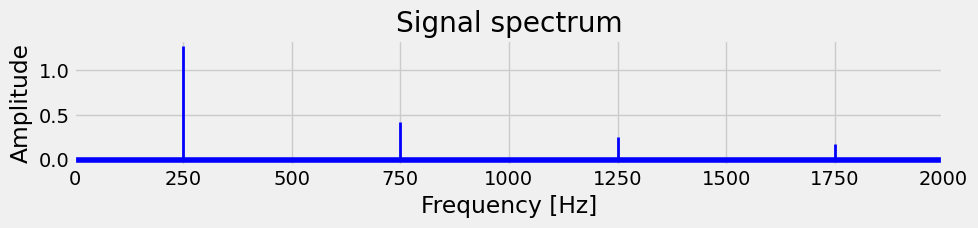

In [250]:
my_freqs = np.arange(1, my_calc.amount_harmonic + 1) * f_3
my_freqs = np.insert(my_freqs, 0, 0)
my_bn_coeffs = np.insert(my_calc.bn, 0, my_calc.a0/2)

plt.figure(figsize=(10, 2.5))
markerline, stemlines, baseline = plt.stem(my_freqs, my_bn_coeffs)

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.xlim(0, 2000)
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()


## <a id='toc1_4_'></a>[Task4](#toc0_)

Добавить шум к сигналу, посмотреть как шум будет изменять спектр сигнала, объяснить результат.

In [255]:
f_4 = 250.0
Fs_4 = 5000 
dt_4 = 1.0 / Fs_4
w_4 = 2 * np.pi * f_4

noise_level = 0.5 
func_noisy_meandr = lambda t: np.sign(np.sin(w_4 * t)) + np.random.normal(0, noise_level)

In [256]:
t_vals_4 = np.arange(0, 1, dt_4)
signal_y_vals_4 = np.array([func_noisy_meandr(t) for t in t_vals_4])

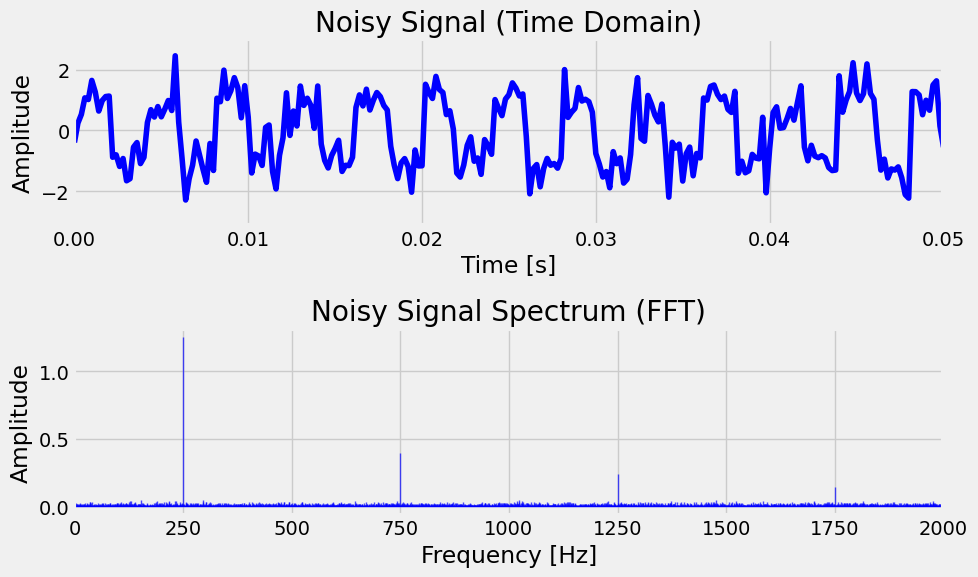

In [259]:
spectrum = np.fft.fft(signal_y_vals_4)

N_4 = signal_y_vals_4.shape[-1]

freq = np.fft.fftfreq(N_4, dt_4)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t_vals_4, signal_y_vals_4, 'b')
plt.title('Noisy Signal (Time Domain)')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N_4//2], 2/N_4 * np.abs(spectrum[:N_4//2]))
plt.setp(stemlines, color='blue', linewidth=1, alpha=0.7) 
plt.setp(markerline, markersize=0)
plt.setp(baseline, color='blue', linewidth=1)

plt.title('Noisy Signal Spectrum (FFT)')
plt.xlabel('Frequency [Hz]')
plt.xlim(0, 2000)
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [ ]:
T_period_4 = 1.0 / f_4

my_calc = FourierSeriesCalculator(func_noisy_meandr, T_period_4, 0, amount_harmonic=15)
my_calc.fit()

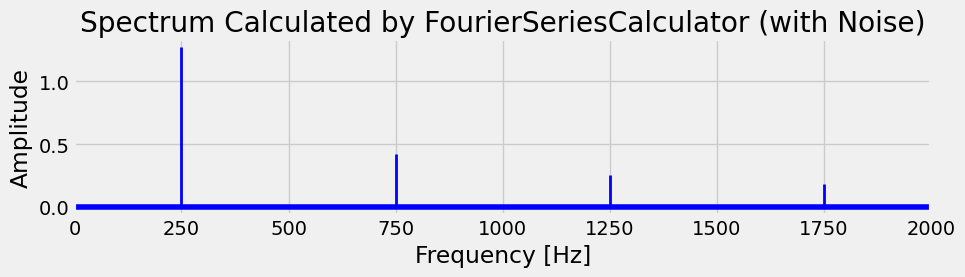

In [261]:
my_freqs = np.arange(1, my_calc.amount_harmonic + 1) * f_4
my_freqs = np.insert(my_freqs, 0, 0)

my_harmonics_ampl = np.sqrt(my_calc.an**2 + my_calc.bn**2)
my_total_coeffs = np.insert(my_harmonics_ampl, 0, my_calc.a0/2)

plt.figure(figsize=(10, 3))
markerline, stemlines, baseline = plt.stem(my_freqs, my_total_coeffs)

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Spectrum Calculated by FourierSeriesCalculator (with Noise)')
plt.xlabel('Frequency [Hz]')
plt.xlim(0, 2000)
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()